<a href="https://colab.research.google.com/github/NK-cloud-hub/testrepo/blob/main/EDA_2nd_file.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset
df = pd.read_csv("df_recipe_performance_machine2.csv")

In [ ]:
# Convert timestamp column to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [ ]:
# Set timestamp as index for time-based analysis
df.set_index("timestamp", inplace=True)

In [ ]:
# Show basic info and statistics
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5292 entries, 2024-01-25 07:00:00+00:00 to 2025-03-31 23:00:00+00:00
Data columns (total 31 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   availability                      5292 non-null   float64
 1   operationalavailability           5292 non-null   float64
 2   efficiency                        5292 non-null   float64
 3   oee                               5292 non-null   float64
 4   qualityrate                       5292 non-null   float64
 5   runningtime                       5292 non-null   int64  
 6   mtbf                              5292 non-null   float64
 7   mttr                              5292 non-null   float64
 8   rejectionrate                     5292 non-null   float64
 9   processed                         5292 non-null   int64  
 10  produce                           5292 non-null   int64  
 11  workingtime          

In [ ]:
print("\nDescriptive Statistics:\n", df.describe())


Descriptive Statistics:
        availability  operationalavailability   efficiency          oee  \
count   5292.000000              5292.000000  5292.000000  5292.000000   
mean      88.269703                64.946165    61.720273    60.797860   
std       25.449731                30.042796    32.354598    32.896786   
min        0.000000                 0.000000     0.000000     0.000000   
25%       91.900871                48.159965    41.120445    37.158065   
50%       99.117128                74.722608    72.843365    72.117078   
75%      100.000000                88.164028    87.578795    87.382267   
max      100.000000               100.000000   100.000000   100.000000   

       qualityrate  runningtime         mtbf         mttr  rejectionrate  \
count  5292.000000  5292.000000  5292.000000  5292.000000    5292.000000   
mean     99.802448  2268.797997  1939.122850    78.049399       0.006690   
std       3.150641  1081.427043  1177.781788   195.578471       0.052791   
min

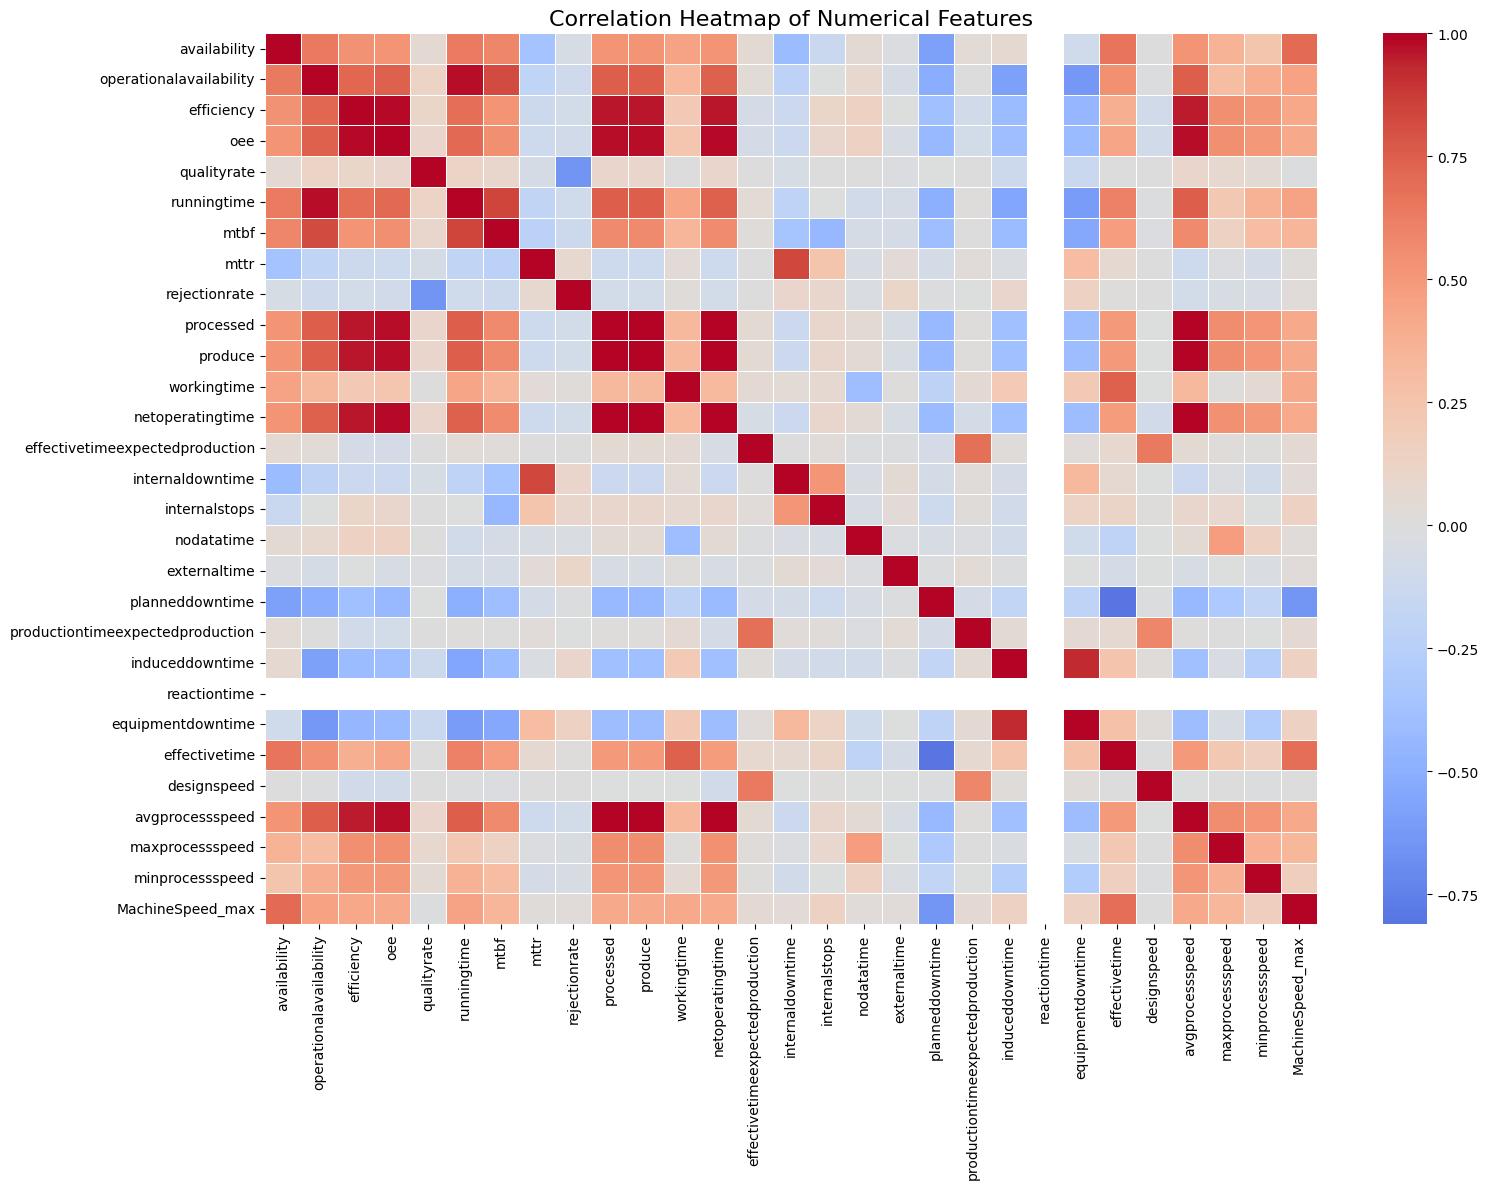

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(df.drop(columns=["recipe", "rank"]).corr(),
            cmap="coolwarm", center=0, annot=False, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

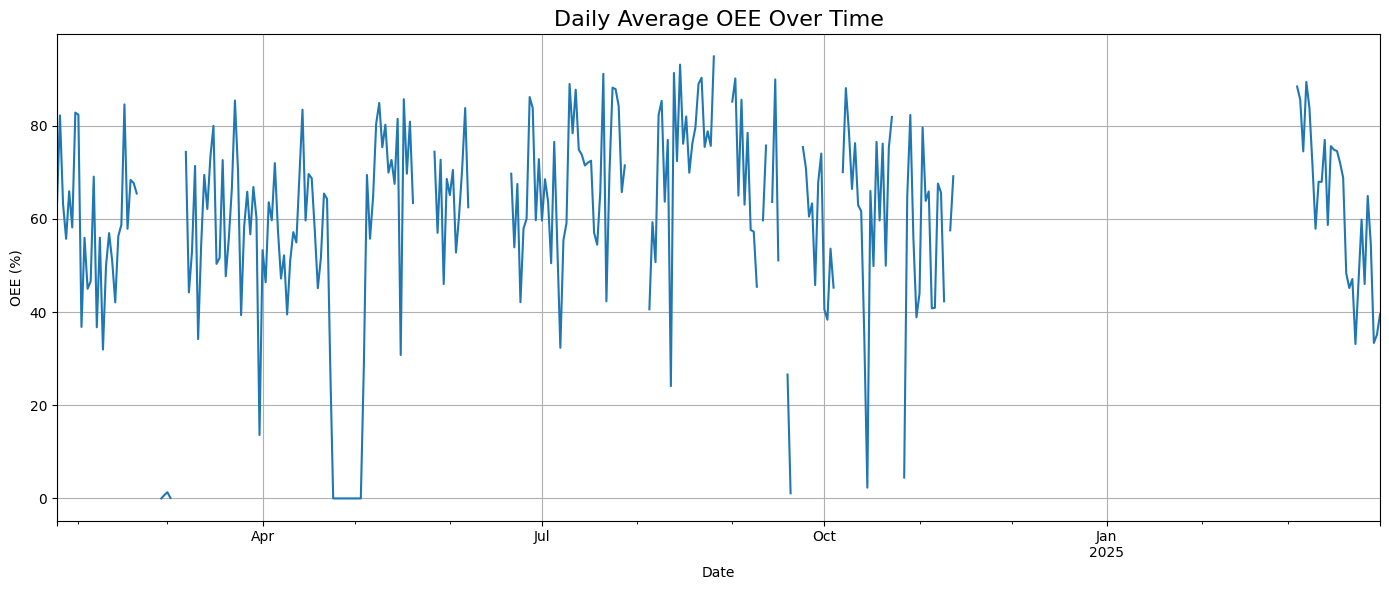

In [ ]:
# OEE(overall equipment effectiveness) Trend Over Time
oee_daily = df["oee"].resample("D").mean()

plt.figure(figsize=(14, 6))
oee_daily.plot()
plt.title("Daily Average OEE Over Time", fontsize=16)
plt.ylabel("OEE (%)")
plt.xlabel("Date")
plt.grid(True)
plt.tight_layout()
plt.show()

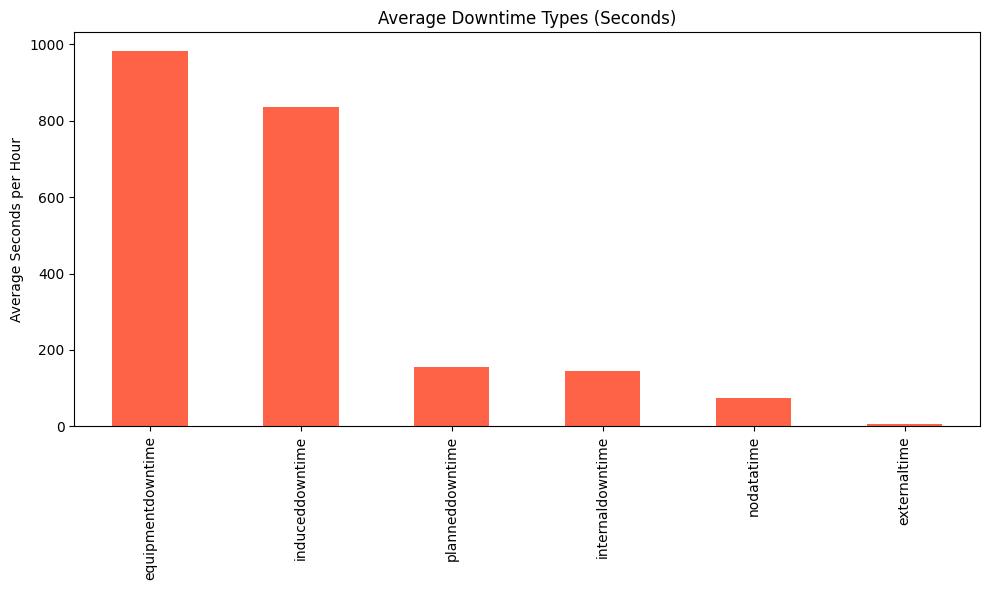

In [ ]:
# Downtime Composition
downtime_cols = [
    "equipmentdowntime",
    "internaldowntime",
    "induceddowntime",
    "planneddowntime",
    "externaltime",
    "nodatatime"
]

downtime_sum = df[downtime_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
downtime_sum.plot(kind="bar", color="tomato")
plt.title("Average Downtime Types (Seconds)")
plt.ylabel("Average Seconds per Hour")
plt.tight_layout()
plt.show()